# Notebook for setting up and prcoessing the RHINO calibration Gibbs Sampler

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from sampler.reader import ObservationReader, ReflectionReader

## Set up observation and reflections

In [66]:
observation = ObservationReader('simulated_data/sim_data.hdf5')
print(np.unique(observation.states_array))

reflection_dict = {'antenna':'simulated_data/antenna_gamma_src.s2p',
                   'heated_load':"simulated_data/heated_load_gamma_src.s2p",
                   'internal_load':'simulated_data/internal_load_gamma_src.s2p',
                   'long_open':'simulated_data/long_open_gamma_src.s2p',
                   'long_short':'simulated_data/long_short_gamma_src.s2p',
                   'open':'simulated_data/open_gamma_src.s2p',
                   'short':'simulated_data/short_gamma_src.s2p',
                   'receiver':'simulated_data/gamma_rec.s2p'}

reflections = ReflectionReader(component_dict=reflection_dict,
                               output_frequencies=observation.freqs,
                               polynomial_interp=True,
                               polynomial_fitting_order=10)

['antenna' 'heated_load' 'internal_load' 'long_open' 'long_short' 'open'
 'short']


/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampl

In [67]:
from sampler.linear_basis import BasisConstructor

## Set up basis functions

In [68]:
gains_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=3,
                               n_freq_modes=5,
                               basis_function='polynomial',
                               time_norm=observation.times[-1] - observation.times[0],
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

unc_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=4,
                               n_freq_modes=4,
                               basis_function='polynomial',
                               time_norm=observation.times[-1] - observation.times[0],
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

cos_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=4,
                               n_freq_modes=4,
                               basis_function='polynomial',
                               time_norm=observation.times[-1] - observation.times[0],
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

sin_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=4,
                               n_freq_modes=4,
                               basis_function='polynomial',
                               time_norm=observation.times[-1] - observation.times[0],
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

rx_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=observation.times[-1] - observation.times[0],
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)


# cal temperature set up: give the same time orders
cal_n_time_modes = 1


ambient_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=cal_n_time_modes,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=observation.times[-1] - observation.times[0],
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

ambient_basis_y = BasisConstructor(observation.times,
                               0,
                               n_time_modes=cal_n_time_modes,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=observation.times[-1] - observation.times[0],
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

heated_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=cal_n_time_modes,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=observation.times[-1] - observation.times[0],
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

heated_basis_y = BasisConstructor(observation.times,
                               0,
                               n_time_modes=cal_n_time_modes,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=observation.times[-1] - observation.times[0],
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)
####

antenna_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=3,
                               basis_function='polynomial',
                               time_norm=observation.times[-1] - observation.times[0],
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

## Construct Operators

In [69]:
from sampler.operator_setup import generate_noise_wave_transfer_matrix
from sampler.operator_setup import generate_non_smooth_source_matrix, generate_smooth_source_matrix, generate_noise_wave_transfer_matrix
# Noise Wave Operator
X_noise_wave, nw_slice_dict = generate_noise_wave_transfer_matrix(observation,
                                                               reflections,
                                                               unc_basis,
                                                               cos_basis,
                                                               sin_basis,
                                                               rx_basis)
print(nw_slice_dict)
print(X_noise_wave.shape)


{'unc': slice(0, 16, None), 'cos': slice(16, 32, None), 'sin': slice(32, 48, None), 'rx': slice(48, 49, None)}
(368640, 49)


## Construct Antenna Operator

In [70]:
X_antenna = generate_smooth_source_matrix(observation,
                                          reflections,
                                          source_basis=antenna_basis,
                                          source_label='antenna')

print(X_antenna.shape)

(368640, 3)


### Combine Noisewave and Antenna Operators

In [71]:
from sampler.operator_setup import concat_and_index_operators

X_ant_noisewave = np.concatenate((X_antenna, X_noise_wave), axis=1)

X_ant_noisewave, ant_noise_wave_slice_dict = concat_and_index_operators([X_antenna,
                                                                         X_noise_wave],
                                                                         label_list=['antenna',
                                                                                     'noise_wave'])

print(ant_noise_wave_slice_dict)

{'antenna': slice(0, 3, None), 'noise_wave': slice(3, 52, None)}


## Construct Calibration Source Operator

In [72]:
print(np.unique(observation.switch_states))

['antenna' 'heated_load' 'internal_load' 'long_open' 'long_short' 'open'
 'short']


In [73]:
X_ambient = generate_smooth_source_matrix(observation, reflections,
                                          source_basis=ambient_basis,
                                          source_label=['internal_load', 'long_open',
                                                        'long_short', 'open', 'short'])
X_heated = generate_smooth_source_matrix(observation, reflections,
                                         source_basis=heated_basis,
                                         source_label='heated_load')

X_calibrator, calibrator_slice_dict = concat_and_index_operators([X_ambient,
                                                                  X_heated],
                                                                  ['ambient',
                                                                   'heated'])


from sampler.priors import generate_smooth_thermistor_operator_matrix

Y_ambient = generate_smooth_thermistor_operator_matrix(observation,
                                          source_basis=ambient_basis_y,
                                          source_label=['internal_load', 'long_open',
                                                        'long_short', 'open', 'short'])


Y_heated = generate_smooth_thermistor_operator_matrix(observation,
                                         source_basis=heated_basis_y,
                                         source_label='heated_load')

Y_calibrator, calibrator_slice_dict_y = concat_and_index_operators([Y_ambient,
                                                                  Y_heated],
                                                                  ['ambient',
                                                                   'heated'])

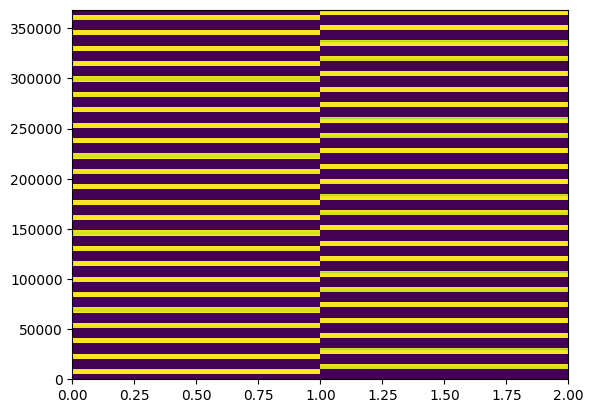

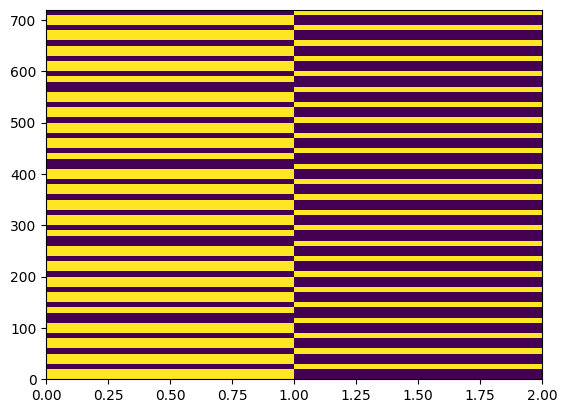

{'ambient': slice(0, 1, None), 'heated': slice(1, 2, None)}


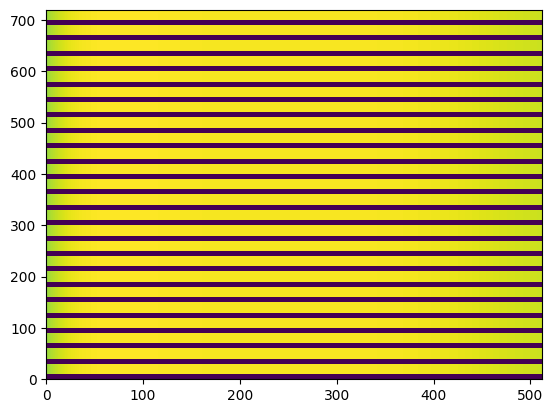

In [74]:

plt.pcolormesh(X_calibrator)
plt.show()

plt.pcolormesh(Y_calibrator)
plt.show()

print(calibrator_slice_dict)

cont = X_calibrator @ np.ones_like(X_calibrator[0])
cont = np.reshape(cont, shape=observation.data_waterfall.shape)
plt.pcolormesh(cont)
plt.show()

In [75]:
print(np.unique(observation.switch_states))

['antenna' 'heated_load' 'internal_load' 'long_open' 'long_short' 'open'
 'short']


### Construct Cal Source Priors

In [76]:
from sampler.priors import setup_probe_cal_priors
cal_source_priors, cal_source_prior_inv_cov = setup_probe_cal_priors(observation,
                                           source_temp_dict={'heated':'heated_load',
                                                             'ambient':['internal_load',
                                                                        'open',
                                                                        'short',
                                                                        'long_open',
                                                                        'long_short']},
                                                                        temp_std=0.25)


In [77]:
### Attempt a Weiner solution fit

from sampler.gibbs_sample import construct_gcr_lhs, construct_gcr_rhs, solve_gcr



cal_source_lhs = construct_gcr_lhs(linear_operator=Y_calibrator,
                                   inv_data_cov=cal_source_prior_inv_cov,
                                   inv_prior_cov=None,)
cal_source_rhs = construct_gcr_rhs(linear_operator=Y_calibrator,
                                   data=cal_source_priors,
                                   inv_data_cov=cal_source_prior_inv_cov,
                                   omega_data=np.zeros_like(cal_source_priors),
                                   priors=None,
                                   inv_prior_cov=None,
                                   weiner_solution=True,)

init_calibrator_solution = solve_gcr(cal_source_lhs, cal_source_rhs,linalg_init=False,
                                     atol=1e-12, rtol=1e-14, maxiter=int(1e6))


print(init_calibrator_solution)


# ambient_amps, heated_amps = init_calibrator_solution[:4], init_calibrator_solution[4:]
# print(ambient_amps)
# print(heated_amps)

# reconstructed_ambient = ambient_basis.basis_matrix @ ambient_amps
# reconstructed_heated = ambient_basis.basis_matrix @ heated_amps

# plt.pcolormesh(np.reshape(reconstructed_ambient, shape=observation.data_waterfall.shape))
# plt.colorbar()
# plt.show()

# plt.pcolormesh(np.reshape(reconstructed_heated, shape=observation.data_waterfall.shape))
# plt.colorbar()
# plt.show()

[292.99835189 442.99823275]


In [78]:
# cal_source_priors = np.array([np.mean(observation.temperatures['ambient']),
#                                      np.mean(observation.temperatures['heated'])])
# cal_source_prior_inv_cov = np.ones_like(cal_source_priors) * (1 / 0.0005)

print(cal_source_prior_inv_cov)

[16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16.
 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16.
 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16.
 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16.
 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16.
 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16.
 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16.
 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16.
 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16.
 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16.
 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16.
 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16.
 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16. 16

In [79]:
## Construct cal source priors from raw temperatures

## Gain Operator

In [80]:
U_gain = gains_basis.basis_matrix
print(U_gain.shape)
# plt.pcolormesh(U_gain)
# plt.show()

(368640, 15)


In [81]:
print(observation.temperatures)

{'heated': array([443.06372429, 442.87229011, 443.00400463, 443.05955302,
       443.00480412, 442.97711427, 443.02888968, 443.04140937,
       442.92350122, 443.08486077, 442.83930887, 442.78704858,
       442.98133838, 443.05235949, 443.00350374, 443.02060814,
       443.06244306, 443.05945105, 443.04888629, 442.96626508,
       442.94499855, 442.95418161, 443.02890269, 442.94256099,
       443.13847084, 443.1215924 , 443.03094791, 442.95095072,
       443.13941742, 442.95226657, 442.94630683, 442.95336497,
       443.11681996, 442.95956573, 443.0276022 , 442.90722925,
       443.17299374, 443.00238122, 443.04649395, 443.02308598,
       443.05215054, 442.89283987, 443.05549456, 442.90002663,
       443.0679874 , 443.12340403, 443.09871227, 442.92489978,
       442.93287677, 442.8851783 , 443.12681998, 443.10468982,
       442.88427412, 443.14429146, 442.93311712, 442.96907456,
       443.09366037, 442.91928702, 443.01181667, 443.04459605,
       442.90125602, 442.99147363, 442.82435

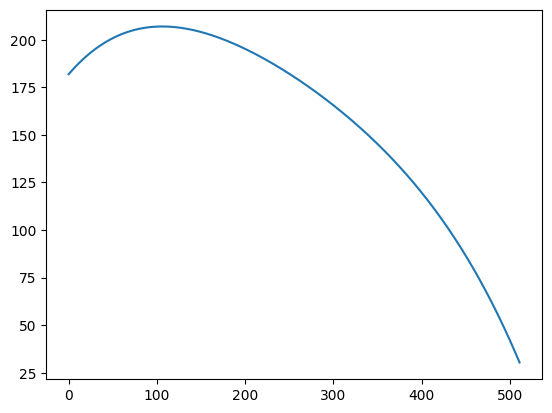

In [82]:
# get an initial guess of the gains params

def init_gain_guess(observation_obj: ObservationReader,
                    reflections_obj: ReflectionReader,
                    gains_basis: BasisConstructor,
                    noise_source_label: str = "heated_load",
                    load_label: str = 'internal_load',
                    noise_source_temp: int | None = None):

    noise_source_mask = (observation_obj.states_array == noise_source_label)
    load_mask = (observation_obj.states_array == load_label)
    p_ns = observation_obj.data_waterfall[noise_source_mask].mean(axis=0)
    p_l = observation_obj.data_waterfall[load_mask].mean(axis=0)

    if noise_source_temp is not None: t_ns = noise_source_temp
    else:
        t_ns = np.mean(observation_obj.temperatures['heated'])
    t_l = np.mean(observation_obj.temperatures['ambient'])

    gamma_rec = reflections_obj.s11_dict['receiver']

    mean_gain = (p_ns - p_l) / ((t_ns - t_l) * (1 - np.power(np.abs(gamma_rec), 2)))

    fitting_gain = np.zeros_like(observation.data_waterfall)
    fitting_gain[:,:] = mean_gain
    fitting_gain = fitting_gain.flatten()
    init_amp_guess = np.linalg.lstsq(gains_basis.basis_matrix, fitting_gain)[0]

    return init_amp_guess

init_gain_amps = init_gain_guess(observation, reflections, gains_basis)

recov_init_gains = gains_basis.basis_matrix @ init_gain_amps
recov_init_gains = np.reshape(recov_init_gains,
                              shape=observation.data_waterfall.shape)

plt.plot(np.mean(recov_init_gains, axis=0))

# Set up Gibbs Sampler

In [83]:
from sampler.gibbs_sample import sample_loop

In [84]:
print(init_calibrator_solution)

[292.99835189 442.99823275]


In [85]:
param_dict = sample_loop(data=observation.data_waterfall.flatten(),
                         N=observation.Nw.flatten(),
                         U_gain=U_gain,
                         X_ant_nw=X_ant_noisewave,
                         X_cal_src=X_calibrator,
                         init_gain_amps=init_gain_amps,
                         init_cal_src_amps=init_calibrator_solution,
                         init_ant_nw_amps=np.ones_like(X_ant_noisewave[0]),
                         cal_src_priors=cal_source_priors,
                         inv_cal_src_prior_cov=cal_source_prior_inv_cov, n_iter=100,
                         fix_cal_source=False,
                         Y_cal_src=Y_calibrator,
                         verbose=True)

d_cont  [1170.87873389 1174.45943585 1175.02365691 ...  838.80063625  853.54882166
  863.85442571]
inv_cont_cov  [0.00029379 0.00028911 0.00028518 ... 0.00160064 0.00160293 0.00160534]
p_ant_nw - 0
[  15822.2911763   -39482.46229932   26570.20176423   50909.2851496
  -81460.72874826    6358.76248033   24507.38757311  -34455.42976706
   28236.38643226   55259.9834882   -47618.72426714   -2522.71443869
   17261.04432255  -32288.53961379   15790.76883772    6897.73802892
  -16549.00689253   13260.99923933   -2959.291891    -37918.28339821
   24148.73916182   79386.60037682  -66005.2650232    94355.89582007
  -97648.95620614 -114112.99968998  119962.91944994  -88058.31614476
  152193.21319975  -25332.32613452  -41101.89024868   25704.77309461
  -58328.67585942   37306.51660855   -4201.04660373    1030.04330755
    2330.68265724   -7625.95380423    4476.51803984  119705.84104338
 -107513.02340676 -139239.44997723  124650.70558979 -143604.07002405
  160793.57768098  104198.53134163 -119081.0

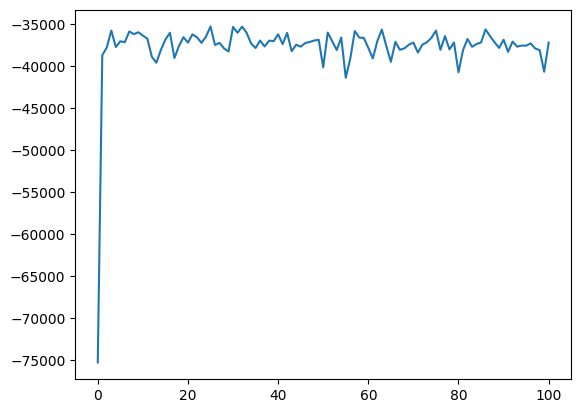

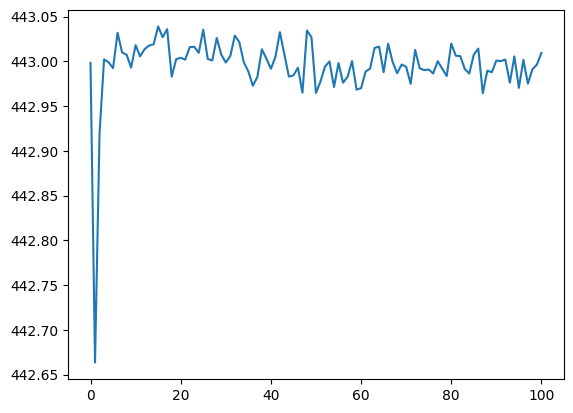

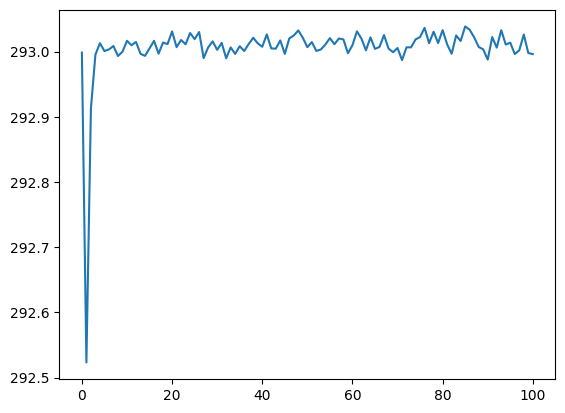

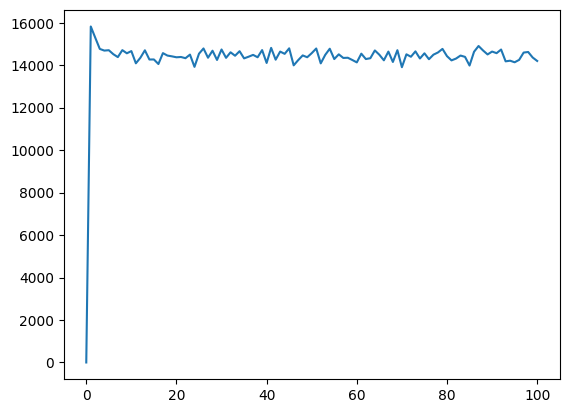

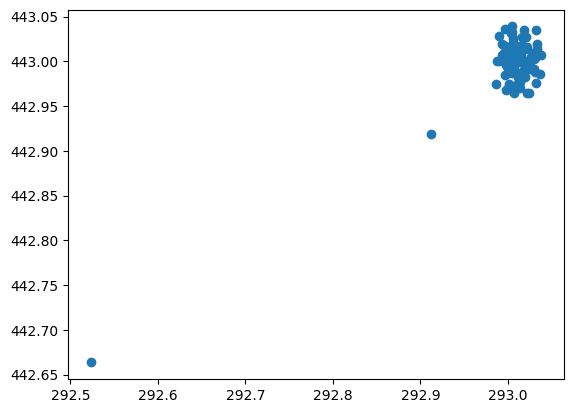

In [86]:
plt.plot(param_dict['all_p_gain'][:,-1])
plt.show()
plt.plot(param_dict['all_p_cal_src'][:, -1])
plt.show()
plt.plot(param_dict['all_p_cal_src'][:, 0])
plt.show()
plt.plot(param_dict['all_p_ant_nw'][:, 0])
plt.show()

plt.scatter(param_dict['all_p_cal_src'][:, 0], param_dict['all_p_cal_src'][:, 1])
plt.show()

In [101]:
param_dict = sample_loop(data=observation.data_waterfall.flatten(),
                         N=observation.Nw.flatten(),
                         U_gain=U_gain,
                         X_ant_nw=X_ant_noisewave,
                         X_cal_src=X_calibrator,
                         init_gain_amps=param_dict['all_p_gain'][-1],
                         init_cal_src_amps=param_dict['all_p_cal_src'][-1],
                         init_ant_nw_amps=param_dict['all_p_ant_nw'][-1],
                         cal_src_priors=cal_source_priors,
                         inv_cal_src_prior_cov=cal_source_prior_inv_cov, n_iter=2500,
                         fix_cal_source=False,
                         Y_cal_src=Y_calibrator,
                         verbose=False,)

Gibbs Sample - 0 / 2500
Gibbs Sample - 50 / 2500
Gibbs Sample - 100 / 2500
Gibbs Sample - 150 / 2500
Gibbs Sample - 200 / 2500
Gibbs Sample - 250 / 2500
Gibbs Sample - 300 / 2500
Gibbs Sample - 350 / 2500
Gibbs Sample - 400 / 2500
Gibbs Sample - 450 / 2500
Gibbs Sample - 500 / 2500
Gibbs Sample - 550 / 2500
Gibbs Sample - 600 / 2500
Gibbs Sample - 650 / 2500
Gibbs Sample - 700 / 2500
Gibbs Sample - 750 / 2500
Gibbs Sample - 800 / 2500
Gibbs Sample - 850 / 2500
Gibbs Sample - 900 / 2500
Gibbs Sample - 950 / 2500
Gibbs Sample - 1000 / 2500
Gibbs Sample - 1050 / 2500
Gibbs Sample - 1100 / 2500
Gibbs Sample - 1150 / 2500
Gibbs Sample - 1200 / 2500
Gibbs Sample - 1250 / 2500
Gibbs Sample - 1300 / 2500
Gibbs Sample - 1350 / 2500
Gibbs Sample - 1400 / 2500
Gibbs Sample - 1450 / 2500
Gibbs Sample - 1500 / 2500
Gibbs Sample - 1550 / 2500
Gibbs Sample - 1600 / 2500
Gibbs Sample - 1650 / 2500
Gibbs Sample - 1700 / 2500
Gibbs Sample - 1750 / 2500
Gibbs Sample - 1800 / 2500
Gibbs Sample - 1850 / 25

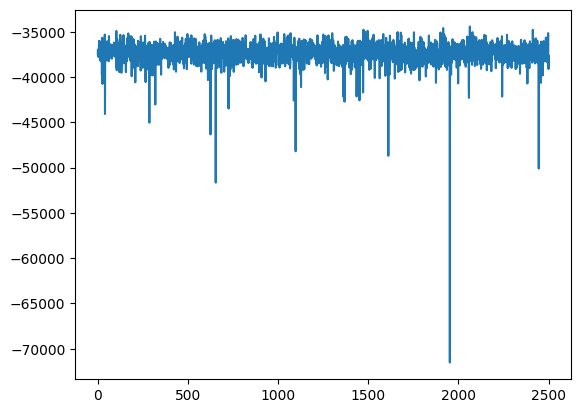

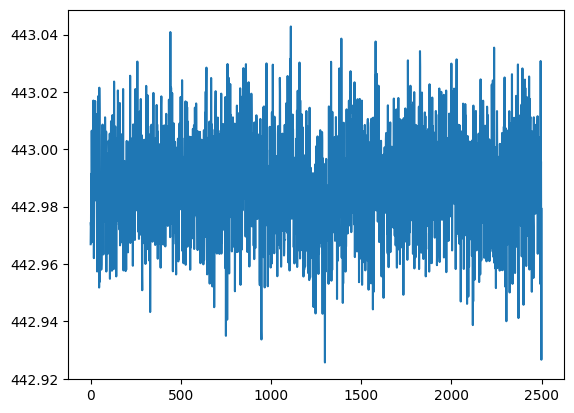

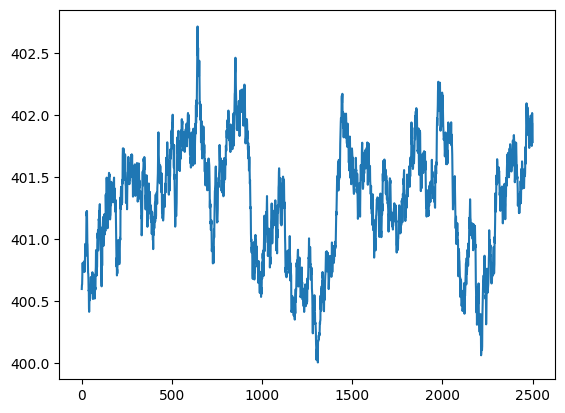

442.9875099810564


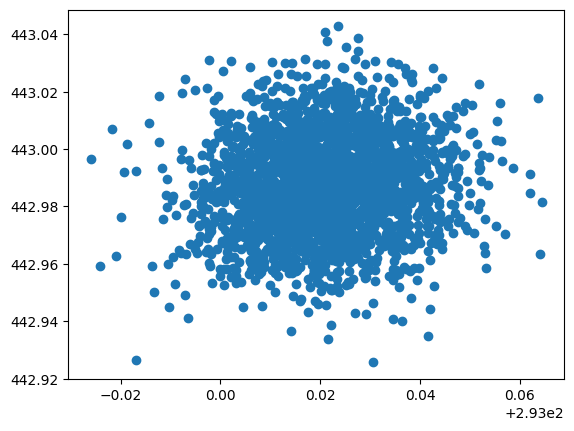

In [102]:
plt.plot(param_dict['all_p_gain'][:,-1])
plt.show()
plt.plot(param_dict['all_p_cal_src'][:, -1])
plt.show()
plt.plot(param_dict['all_p_ant_nw'][:, -1])
plt.show()

print(np.mean(param_dict['all_p_cal_src'][:, -1]))

plt.scatter(param_dict['all_p_cal_src'][:, 0], param_dict['all_p_cal_src'][:, 1])
plt.show()



[  956.80514131 -1723.25601839   569.47467025   190.29000002
  -456.92837254   510.61847406   357.08716794  -405.04560337
  -914.71636471  2588.1476356  -2523.31051228   842.58907126
  -926.76524322  2832.41664788 -2836.43413001  1233.38831719
  1237.4767891  -1918.08936468    28.15961018   646.93581416
 -1146.33090494  1296.163058    1015.96922273 -1162.42415873
  -460.05121406  1914.65043916 -2520.60759921  1068.77192368
  -655.4567052   1881.27112008 -1751.17401095   573.83274236
    58.96333333 -1129.22044879  2254.12009481 -1172.75742282
  1092.31492032 -2481.90739334  1487.35382465  -105.39542802
   891.80215168 -2628.09255918  2628.13883545  -895.91002055
  1121.91624065 -3440.92162991  3468.76163492 -1091.43270134
   401.29480101]


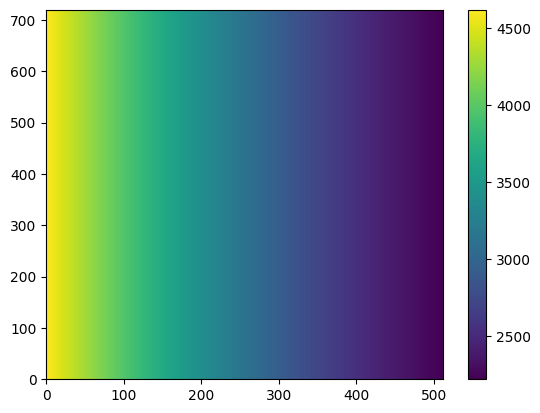

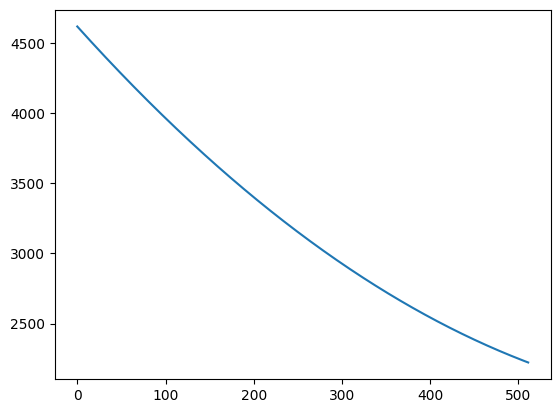

In [103]:
# Recovered Antenna

median_p_ant_nw = np.mean(param_dict['all_p_ant_nw'], axis=0)
median_p_ant = median_p_ant_nw[:len(X_antenna[0])]
median_p_nw = median_p_ant_nw[len(X_antenna[0]):]
print(median_p_nw)


reconstructed_antenna = antenna_basis.basis_matrix @ median_p_ant
reconstructed_antenna = np.reshape(reconstructed_antenna, shape=observation.data_waterfall.shape)

plt.pcolormesh(reconstructed_antenna)
plt.colorbar()
plt.show()

plt.plot(reconstructed_antenna.mean(axis=0))
plt.show()

[ 9.10290895e+02 -7.31817951e+03  8.13070196e+03  9.24420473e+02
 -2.11718833e+03 -1.16682958e+03  8.56635728e+03 -9.96858464e+03
  1.52324711e+02  1.94249135e+03 -3.44396561e+04  1.37225825e+05
 -2.09382221e+05  1.44132452e+05 -3.72496583e+04]


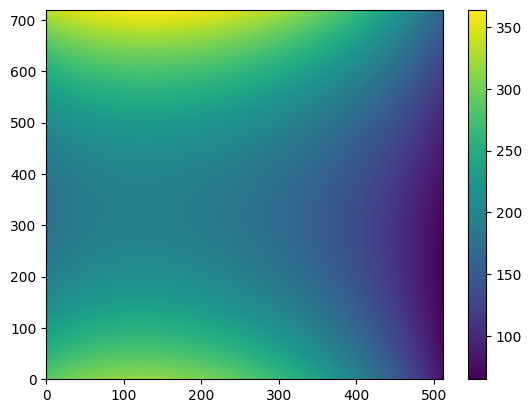

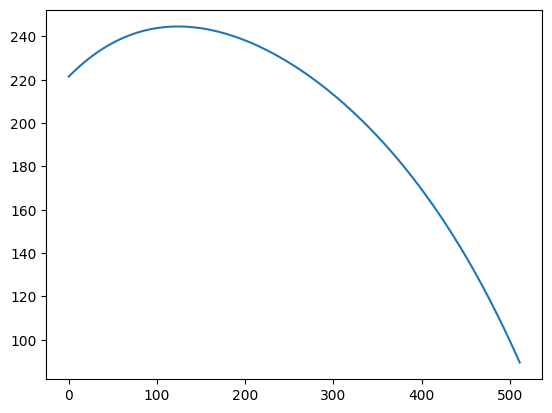

In [104]:
median_gains = np.median(param_dict['all_p_gain'], axis=0)

print(median_gains)

reconstructed_gains = gains_basis.basis_matrix @ median_gains

reconstructed_gains = np.reshape(reconstructed_gains, shape=observation.data_waterfall.shape)

plt.pcolormesh(reconstructed_gains)
plt.colorbar()
plt.show()

plt.plot(np.mean(reconstructed_gains, axis=0))
plt.show()

In [105]:
import h5py
sim_filepath = 'simulated_data/sim_data.hdf5_sim'
with h5py.File(sim_filepath) as f:
    t_unc_sim = f['t_unc'][()]
    t_sin_sim = f['t_sin'][()]
    t_cos_sim = f['t_cos'][()]
    t_rx_sim = f['t_0'][()]
    gain_sim = f['gains'][()]

## Gain Recovery

[ 9.10290895e+02 -7.31817951e+03  8.13070196e+03  9.24420473e+02
 -2.11718833e+03 -1.16682958e+03  8.56635728e+03 -9.96858464e+03
  1.52324711e+02  1.94249135e+03 -3.44396561e+04  1.37225825e+05
 -2.09382221e+05  1.44132452e+05 -3.72496583e+04]


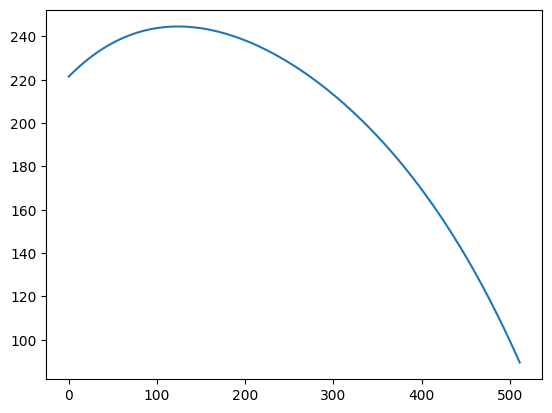

In [106]:
median_gains = np.median(param_dict['all_p_gain'], axis=0)
mean_gains = np.mean(param_dict['all_p_gain'], axis=0)
print(median_gains)

reconstructed_gains = gains_basis.basis_matrix @ median_gains

reconstructed_gains = np.reshape(reconstructed_gains, shape=observation.data_waterfall.shape)

plt.plot(np.mean(reconstructed_gains, axis=0))
plt.show()

In [107]:
def compare_sim_and_recontructed(simulated_surface,
                                 basis_obj:BasisConstructor,
                                 amplitudes,
                                 times,
                                 freqs,
                                 cmap_rec='viridis',
                                 cmap_res='RdBu',
                                 perc_diff=False,
                                 surface_label='',
                                 residvminvmax=None,
                                 figsize=(10,8)):
    fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, sharex=True, layout='constrained',
                                        figsize=figsize)

    recovered_surface = basis_obj.basis_matrix @ amplitudes
    recovered_surface = np.reshape(recovered_surface, shape=simulated_surface.shape)

    vmin = np.min(np.array([simulated_surface, recovered_surface]))
    vmax = np.max(np.array([simulated_surface, recovered_surface]))
    
    im1 = ax1.pcolormesh(freqs, times, simulated_surface, cmap=cmap_rec, vmin=vmin, vmax=vmax)
    ax1.set_title('True Simulated')

    im2 = ax2.pcolormesh(freqs, times, recovered_surface, cmap=cmap_rec, vmin=vmin, vmax=vmax)
    ax2.set_title('Recovered')

    if perc_diff:
        res = 200 * (recovered_surface - simulated_surface) / (recovered_surface+simulated_surface)
    else:
        res = recovered_surface - simulated_surface
    

    if residvminvmax is not None:
        im3 = ax3.pcolormesh(freqs, times, res, cmap=cmap_res,
                                 vmin=-residvminvmax,
                                 vmax=residvminvmax)
    else:
        im3 = ax3.pcolormesh(freqs, times, res, cmap=cmap_res)

    fig.colorbar(im1, ax=[ax1, ax2], label=surface_label)

    if perc_diff:
        res_label='% Difference'
    else:
        res_label='Residual [K]'
    fig.colorbar(im3, ax=ax3, label=res_label)

    fig.supxlabel('Freqs [Hz]')
    fig.supylabel('Time [s]')
    plt.show()
    

## Noise Wave Param Recovery

In [108]:
param_dict['all_p_ant_nw'][ant_noise_wave_slice_dict['noise_wave']]

mean_ant_nw = param_dict['all_p_ant_nw'].mean(axis=0)

median_ant_nw = np.mean(param_dict['all_p_ant_nw'], axis=0)

# print(ant_noise_wave_slice_dict['noise_wave'])

mean_nw = median_ant_nw[ant_noise_wave_slice_dict['noise_wave']]
print(nw_slice_dict)

mean_unc = mean_nw[nw_slice_dict['unc']]
mean_cos = mean_nw[nw_slice_dict['cos']]
mean_sin = mean_nw[nw_slice_dict['sin']]
mean_rx = mean_nw[nw_slice_dict['rx']]

print(mean_unc, mean_cos, mean_sin, mean_rx)

{'unc': slice(0, 16, None), 'cos': slice(16, 32, None), 'sin': slice(32, 48, None), 'rx': slice(48, 49, None)}
[  956.80514131 -1723.25601839   569.47467025   190.29000002
  -456.92837254   510.61847406   357.08716794  -405.04560337
  -914.71636471  2588.1476356  -2523.31051228   842.58907126
  -926.76524322  2832.41664788 -2836.43413001  1233.38831719] [ 1237.4767891  -1918.08936468    28.15961018   646.93581416
 -1146.33090494  1296.163058    1015.96922273 -1162.42415873
  -460.05121406  1914.65043916 -2520.60759921  1068.77192368
  -655.4567052   1881.27112008 -1751.17401095   573.83274236] [   58.96333333 -1129.22044879  2254.12009481 -1172.75742282
  1092.31492032 -2481.90739334  1487.35382465  -105.39542802
   891.80215168 -2628.09255918  2628.13883545  -895.91002055
  1121.91624065 -3440.92162991  3468.76163492 -1091.43270134] [401.29480101]


In [109]:
figsize=(5,10)

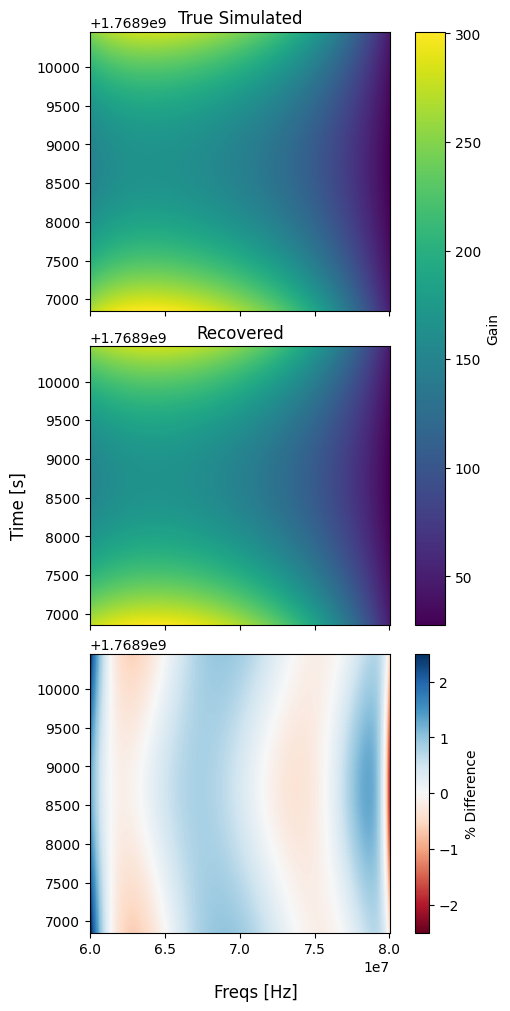

In [110]:
compare_sim_and_recontructed(gain_sim,
                             gains_basis,
                             mean_gains,
                             observation.times,
                             observation.freqs,
                             surface_label='Gain',
                             perc_diff=True,
                             residvminvmax=2.5,
                             figsize=figsize)

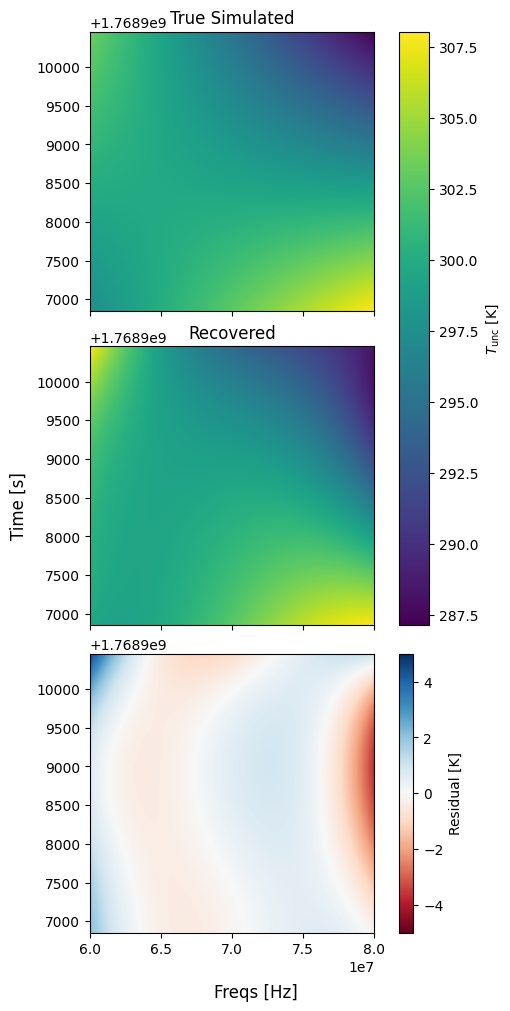

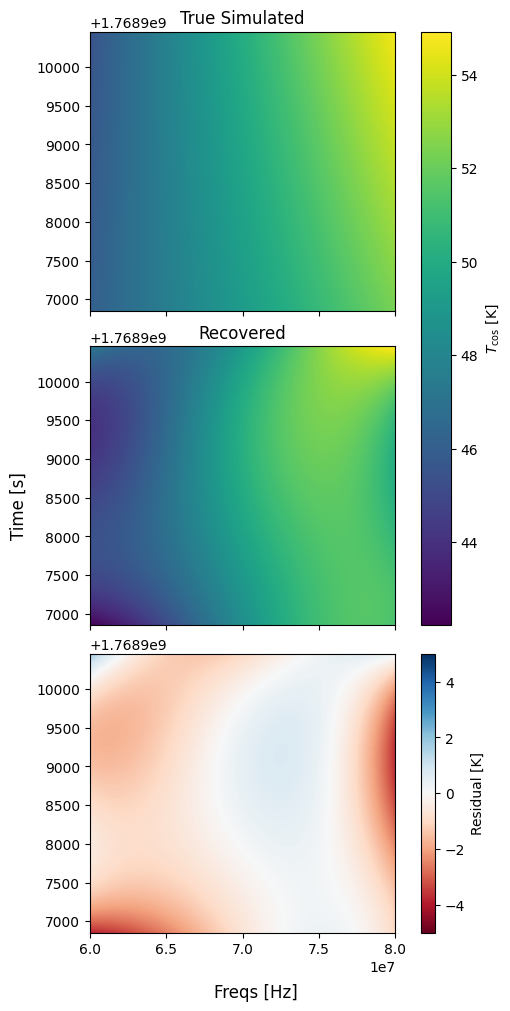

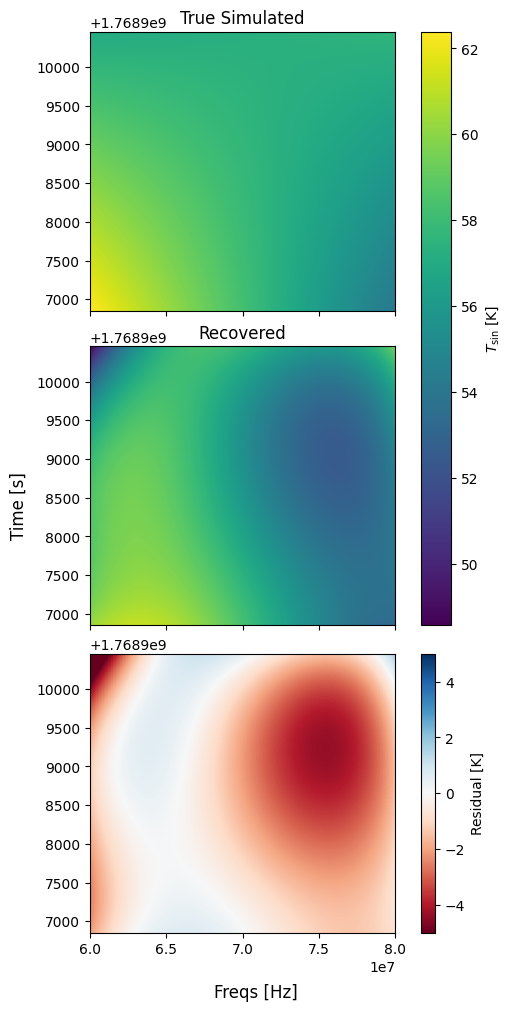

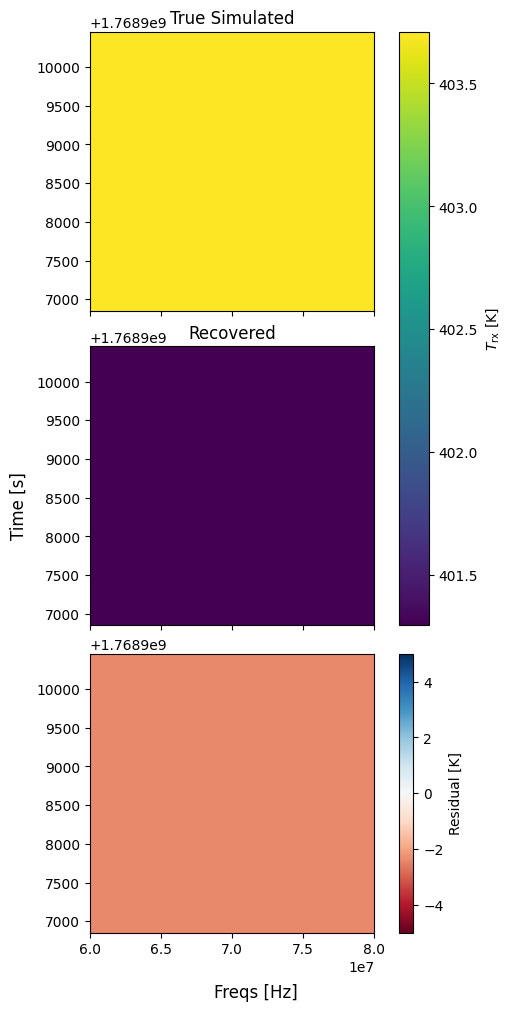

In [111]:
figsize=(5,10)

compare_sim_and_recontructed(t_unc_sim,
                             unc_basis,
                             mean_unc,
                             observation.times,
                             observation.freqs,
                             residvminvmax=5,
                             surface_label=r'$T_{\rm unc}$ [K]',
                             figsize=figsize)
compare_sim_and_recontructed(t_cos_sim,
                             cos_basis,
                             mean_cos,
                             observation.times,
                             observation.freqs,
                             residvminvmax=5,
                             surface_label=r'$T_{\rm cos}$ [K]',
                             figsize=figsize)
compare_sim_and_recontructed(t_sin_sim,
                             sin_basis,
                             mean_sin,
                             observation.times,
                             observation.freqs,
                             residvminvmax=5,
                             surface_label=r'$T_{\rm sin}$ [K]',
                             figsize=figsize)
compare_sim_and_recontructed(t_rx_sim,
                             rx_basis,
                             mean_rx,
                             observation.times,
                             observation.freqs,
                             residvminvmax=5,
                             surface_label=r'$T_{\rm rx}$ [K]',
                             figsize=figsize)

In [112]:
def plot_corner(
    chains: np.ndarray,
    labels: list[str] | None = None,
    truths: list[float] | None = None,
    title: str | None = None,
    **corner_kwargs,
):
    """
    Plot posterior densities and parameter correlations using corner.py.

    Parameters
    ----------
    chains : np.ndarray
        Array of parameter chains with shape:
        (n_samples, n_parameters)

    labels : list[str], optional
        Names of the parameters.

    truths : list[float], optional
        True/reference values for each parameter.

    title : str, optional
        Optional figure title.

    **corner_kwargs
        Additional keyword arguments passed to corner.corner().

    Returns
    -------
    fig : matplotlib.figure.Figure
        The generated corner plot figure.
    """

    import corner
    chains = np.asarray(chains)

    if chains.ndim != 2:
        raise ValueError(
            f"chains must be 2D with shape (n_samples, n_parameters), "
            f"got shape {chains.shape}"
        )

    n_parameters = chains.shape[1]

    if labels is not None and len(labels) != n_parameters:
        raise ValueError(
            f"Expected {n_parameters} labels, got {len(labels)}"
        )

    if truths is not None and len(truths) != n_parameters:
        raise ValueError(
            f"Expected {n_parameters} truths, got {len(truths)}"
        )

    fig = corner.corner(
        chains,
        labels=labels,
        truths=truths,
        **corner_kwargs,
    )

    if title is not None:
        fig.suptitle(title)

    return fig


[293.0265695  293.01986779 293.03966584 ... 293.023677   292.98311997
 293.02439955] [442.96689749 442.97453014 442.97337084 ... 442.96078558 442.92662066
 442.97922272]


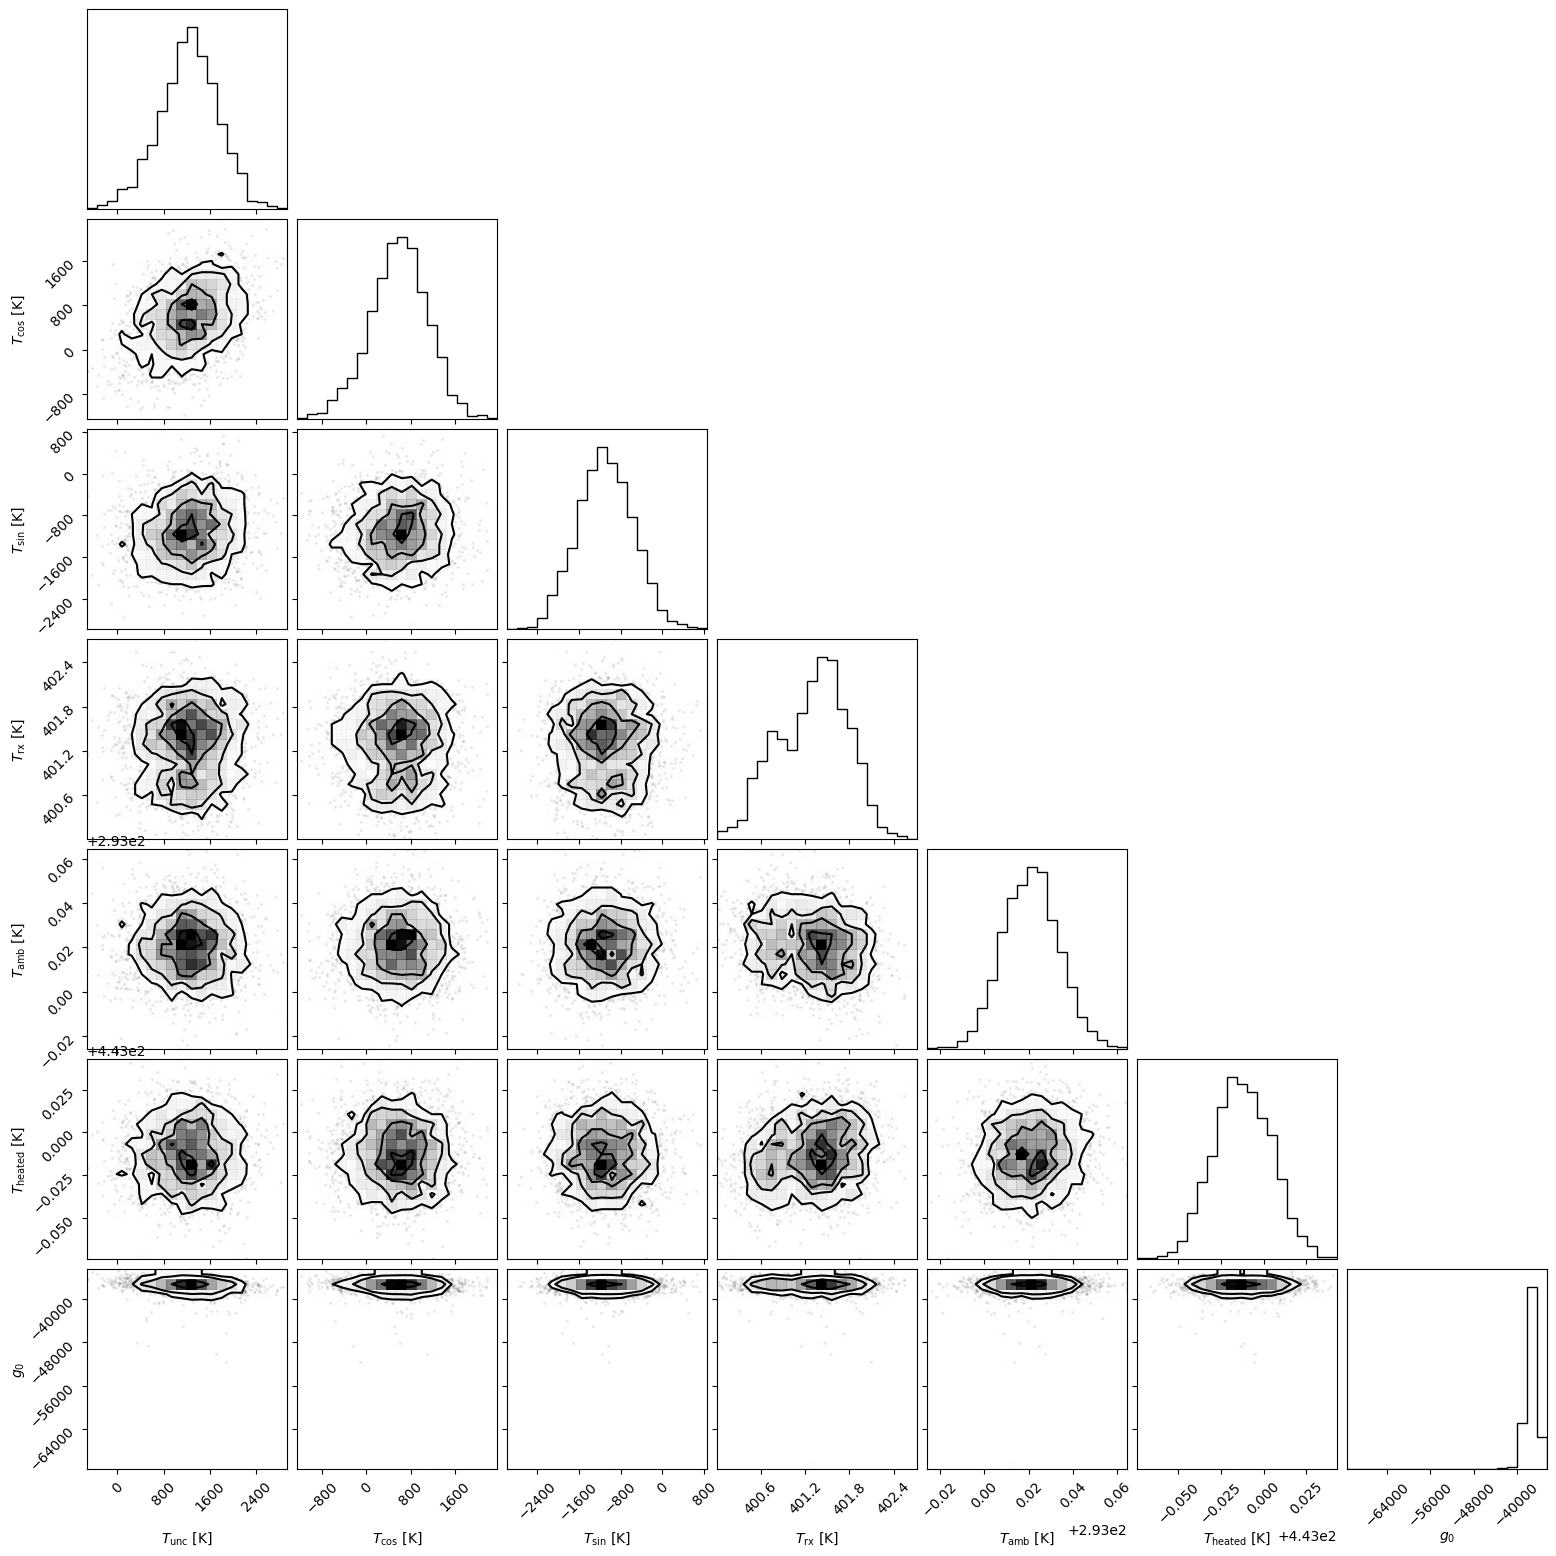

In [113]:
noise_wave_chains = param_dict['all_p_ant_nw'][:,ant_noise_wave_slice_dict['noise_wave']]


t_unc_chains = noise_wave_chains[:,nw_slice_dict['unc']]
t_sin_chains = noise_wave_chains[:,nw_slice_dict['sin']]
t_cos_chains = noise_wave_chains[:,nw_slice_dict['cos']]
t_rx_chains = noise_wave_chains[:,nw_slice_dict['rx']]

t_amb_chains = param_dict['all_p_cal_src'][:,0]
t_heated_chains = param_dict['all_p_cal_src'][:,1]
print(t_amb_chains, t_heated_chains)

param_dict['all_p_gain']

gain_chain = param_dict['all_p_gain'][:,-1]



chains = np.column_stack([
    t_unc_chains[:,-1],
    t_cos_chains[:,-1],
    t_sin_chains[:,-1],
    t_rx_chains[:,-1],
    t_amb_chains,
    t_heated_chains,
    gain_chain,
])

fig = plot_corner(
    chains,
    labels=[
        r'$T_{\rm unc}$ [K]',
        r'$T_{\rm cos}$ [K]',
        r'$T_{\rm sin}$ [K]',
        r'$T_{\rm rx}$ [K]',
        r'$T_{\rm amb}$ [K]',
        r'$T_{\rm heated}$ [K]',
        r'$g_0$'
    ],
)

plt.show()